<a href="https://colab.research.google.com/github/nalba97/TEXT-CSV-word-checker/blob/main/Week_4_Lab_Demo_k_Nearest_Neighbors_(KNN).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 Lab Demo: k-Nearest Neighbors (kNN)

**Background**

The data was collected to identify whether a tumor biopsy was malignant or benign. A malignant tumor requires medical intervention.

Our task then is to develop the best possible diagnostic machine learning algorithm in order to assist the patient’s medical team in determining whether the tumor is malignant or not.

**Variables**
Ten real-valued features are computed for each cell nucleus:

a) radius8 (mean of distances from center to points on the perimeter)

b) texture (standard deviation of gray-scale values)

c) perimeter

d) area

e) smoothness (local variation in radius lengths)

f) compactness (perimeter^2 / area - 1.0)

g) concavity (severity of concave portions of the contour)

h) concave points (number of concave portions of the contour)

i) symmetry

j) fractal dimension ("coastline approximation" - 1)

k) **Diagnosis** (M = malignant, B = benign)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features were computed for each image, resulting in 30 features. For instance, field 3 is Mean Radius, field 13 is Radius SE, field 23 is Worst Radius.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/My Drive/Colab Notebooks/Datafiles/breast_cancer.csv"

In [ ]:
import pandas as pd
cancer = pd.read_csv(path)

In [ ]:
# assign variables to X and y
X = cancer.iloc[: ,0:30].values
y = cancer.iloc[ :, 30].values

In [ ]:
#labelencode the target variable
from sklearn.preprocessing import LabelEncoder
labelencoder_cancer = LabelEncoder()
y = labelencoder_cancer.fit_transform(cancer['diagnosis'].values)

## Standardize the features before perform KNN


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_standardized, y, test_size = 0.25, random_state = 0)

## create a simple k-nearest neighbor classifier

In [ ]:
# knn with 4 nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

knn_4 = KNeighborsClassifier(n_neighbors=4)

knn_4.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=4)

In [ ]:
from sklearn import metrics
from sklearn.metrics import accuracy_score

y_pred_4 = knn_4.predict(X_test)
print("Accuracy:{:.3f}".format(metrics.accuracy_score(y_test, y_pred_4)))

Accuracy:0.958


In [ ]:
# knn with 8 nearest neighbors

knn_8 = KNeighborsClassifier(n_neighbors=8)

knn_8.fit(X_train, y_train)

y_pred_8 = knn_8.predict(X_test)

print("Accuracy:{:.3f}".format(metrics.accuracy_score(y_test, y_pred_8)))

Accuracy:0.944


In [ ]:
# knn with 8 nearest neighbors

knn_11 = KNeighborsClassifier(n_neighbors=11)

knn_11.fit(X_train, y_train)

y_pred_11 = knn_11.predict(X_test)

print("Accuracy:{:.3f}".format(metrics.accuracy_score(y_test, y_pred_11)))

Accuracy:0.951


## Identify the best k

Given different the number of nearest neighbors may have different model performance on test set, the best way we can do is to set a range of the k, and ask the python to perform analysis with each k in this range, and return the model performance on the test for each k in the range


In [ ]:

# Train a classifier for different values of k
results = []
for k in range(1, 10):
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    results.append({
        'k': k,
        'accuracy': accuracy_score(y_test, y_pred)
    })

# Convert results to a pandas data frame
results = pd.DataFrame(results)
print(results)

   k  accuracy
0  1  0.944056
1  2  0.951049
2  3  0.944056
3  4  0.958042
4  5  0.951049
5  6  0.951049
6  7  0.944056
7  8  0.944056
8  9  0.951049


## Visualize the performance on different k

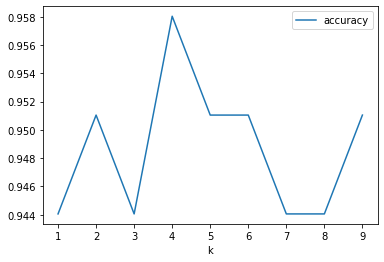

In [ ]:
results.plot(x="k", y="accuracy", kind="line")